# Plot: Total Lite Score vs Recent Frames

This notebook reads a tidy CSV of `sta+ / sta- / osc` experiment results and renders all three families as line plots on the same figure.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


In [7]:
# Plot configuration
FIGSIZE = (9.4, 5.8)
PNG_DPI = 600
PDF_DPI = 600
LINE_WIDTH = 2.4
MARKER_SIZE = 7.0
GRID_ALPHA = 0.22
Y_PAD_MIN = 0.35
Y_PAD_SCALE = 0.16
X_AXIS_LABEL = "Recent Frames"
Y_AXIS_LABEL = "Vbench Score"
PLOT_TITLE = "" # 取消标题
SAVEFIG_BBOX = "tight"
FAMILY_ORDER = ["sta_plus", "sta_minus", "osc"]
FAMILY_LABELS = {
    "sta_plus": "Anchor Head",
    "sta_minus": "Veil Head",
    "osc": "Wave Head",
}
FAMILY_COLORS = {
    "sta_plus": "#4C78A8",
    "sta_minus": "#F58518",
    "osc": "#54A24B",
}
FAMILY_MARKERS = {
    "sta_plus": "o",
    "sta_minus": "s",
    "osc": "^",
}

PLOT_RC = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 0.9,
    "savefig.bbox": SAVEFIG_BBOX,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

plt.rcParams.update(PLOT_RC)


In [8]:
# Data configuration
TASK_DIRNAME = "26Mar14-RecentSweep"
CSV_FILENAME = "total_lite_recent_curves.csv"
PNG_FILENAME = "total_lite_recent_lines.png"
PDF_FILENAME = "total_lite_recent_lines.pdf"


def resolve_repo_root() -> Path:
    """Support running the notebook from repo root or from the notebook directory."""
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        data_file = candidate / "data" / TASK_DIRNAME / CSV_FILENAME
        if data_file.exists():
            return candidate
    raise FileNotFoundError(f"Could not locate data/{TASK_DIRNAME}/{CSV_FILENAME}")


REPO_ROOT = resolve_repo_root()
DATA_DIR = REPO_ROOT / "data" / TASK_DIRNAME
FIG_DIR = REPO_ROOT / "figures" / TASK_DIRNAME
FIG_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = DATA_DIR / CSV_FILENAME
PNG_OUTPUT_PATH = FIG_DIR / PNG_FILENAME
PDF_OUTPUT_PATH = FIG_DIR / PDF_FILENAME
{
    "csv_path": str(CSV_PATH),
    "png_output": str(PNG_OUTPUT_PATH),
    "pdf_output": str(PDF_OUTPUT_PATH),
}


{'csv_path': '/home/winbeau/Tools/jupyter-plot/data/26Mar14-RecentSweep/total_lite_recent_curves.csv',
 'png_output': '/home/winbeau/Tools/jupyter-plot/figures/26Mar14-RecentSweep/total_lite_recent_lines.png',
 'pdf_output': '/home/winbeau/Tools/jupyter-plot/figures/26Mar14-RecentSweep/total_lite_recent_lines.pdf'}

In [9]:
def load_recent_curves(csv_path: str | Path) -> pd.DataFrame:
    """Load and sort the tidy Recent-vs-Total-Lite dataset."""
    df = pd.read_csv(csv_path)
    expected_columns = {
        "family",
        "recent_frames",
        "method_label",
        "total_lite_score_mean",
        "total_lite_score_std",
    }
    missing = expected_columns.difference(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    df["family"] = pd.Categorical(df["family"], categories=FAMILY_ORDER, ordered=True)
    df = df.sort_values(["family", "recent_frames"], kind="stable").reset_index(drop=True)
    return df


In [10]:
curves = load_recent_curves(CSV_PATH)
curves.head()


,family,recent_frames,method_label,total_lite_score_mean,total_lite_score_std
0,sta_plus,1,Sta Plus R1,77.938,3.639
1,sta_plus,3,Sta Plus R3,79.719,4.486
2,sta_plus,5,Sta Plus R5,80.444,4.061
3,sta_plus,10,Sta Plus R10,80.665,3.970
4,sta_plus,15,Sta Plus R15,80.845,3.810


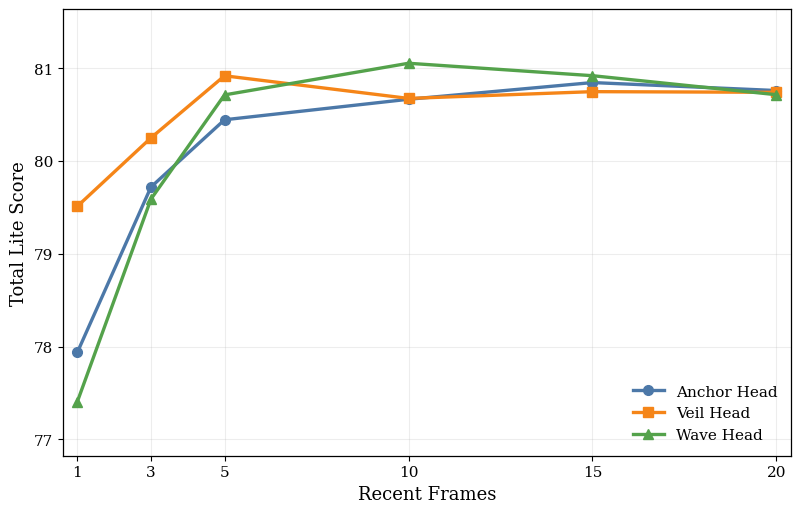

(PosixPath('/home/winbeau/Tools/jupyter-plot/figures/26Mar14-RecentSweep/total_lite_recent_lines.png'),
 PosixPath('/home/winbeau/Tools/jupyter-plot/figures/26Mar14-RecentSweep/total_lite_recent_lines.pdf'))

In [11]:
def plot_total_lite_recent_lines(
    csv_path: str | Path,
    png_output_path: str | Path,
    pdf_output_path: str | Path,
) -> tuple[Path, Path]:
    """Render the Total Lite Score line chart for all three method families."""
    df = load_recent_curves(csv_path)
    fig, ax = plt.subplots(figsize=FIGSIZE)

    for family in FAMILY_ORDER:
        subset = df[df["family"] == family]
        ax.plot(
            subset["recent_frames"],
            subset["total_lite_score_mean"],
            label=FAMILY_LABELS[family],
            color=FAMILY_COLORS[family],
            marker=FAMILY_MARKERS[family],
            linewidth=LINE_WIDTH,
            markersize=MARKER_SIZE,
        )

    score_min = float(df["total_lite_score_mean"].min())
    score_max = float(df["total_lite_score_mean"].max())
    score_span = score_max - score_min
    y_pad = max(Y_PAD_MIN, score_span * Y_PAD_SCALE)

    ax.set_xlim(min(df["recent_frames"]) - 0.4, max(df["recent_frames"]) + 0.4)
    ax.set_xticks(sorted(df["recent_frames"].unique()))
    ax.set_ylim(score_min - y_pad, score_max + y_pad)
    ax.set_xlabel(X_AXIS_LABEL)
    ax.set_ylabel(Y_AXIS_LABEL)
    ax.set_title(PLOT_TITLE)
    ax.grid(alpha=GRID_ALPHA)
    ax.legend(frameon=False)

    png_output = Path(png_output_path)
    pdf_output = Path(pdf_output_path)
    plt.savefig(png_output, dpi=PNG_DPI, bbox_inches=SAVEFIG_BBOX)
    plt.savefig(pdf_output, dpi=PDF_DPI, bbox_inches=SAVEFIG_BBOX)
    if "get_ipython" in globals() and get_ipython() is not None:
        display(fig)
    plt.close(fig)
    return png_output, pdf_output


plot_total_lite_recent_lines(CSV_PATH, PNG_OUTPUT_PATH, PDF_OUTPUT_PATH)
